# HarvestBridge Crop Recommendation Training Notebook

In [2]:
# ============================================
# IMPORTS
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
import sys
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
import joblib
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance


In [3]:
# CONFIGURATION
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from harvestbridge_features import add_crop_features

DATA_DIR=PROJECT_ROOT/"dataset"
DATASET=DATA_DIR/"HarvestBridge.csv"
OUTPUT_DIR=PROJECT_ROOT/"models"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_PATH=OUTPUT_DIR/"crop_model_pipeline.pkl"
METADATA_PATH=OUTPUT_DIR/"crop_model_metadata.pkl"
TARGET="Recommended_Crop"
DROP_COLUMNS=["Farmer_ID"]
TEST_SIZE=0.2
CV_SPLITS=5
N_JOBS=1
RANDOM_STATE=42


In [4]:
# LOAD DATA
df=pd.read_csv(DATASET)
print(df.head())
print(df.shape)
print(df.isnull().sum())
print("Duplicates:",df.duplicated().sum())


  Farmer_ID Season      District   Soil_Type  Temperature_C  Rainfall_mm  \
0    F00001   Yala       Badulla        Loam           33.7        238.0   
1    F00002   Maha    Monaragala  Sandy Loam           24.9        292.0   
2    F00003   Maha    Batticaloa       Sandy           24.7        260.0   
3    F00004   Yala        Jaffna  Sandy Loam           28.5        197.0   
4    F00005   Maha  Anuradhapura   Clay Loam           28.7        397.0   

   Humidity_pct   pH Previous_Crop  Previous_Yield_t_ha Market_Demand  \
0          64.0  7.2        Potato                 21.4          High   
1          63.0  5.5        Carrot                  3.8          High   
2          74.0  6.0         Beans                 21.5        Medium   
3          92.0  5.9           NaN                 21.6          High   
4          81.0  6.3         Maize                  5.2        Medium   

  Recommended_Crop  
0           Potato  
1            Maize  
2            Onion  
3          Brinjal  

In [5]:
# CLEAN DATA
df=df.drop_duplicates().reset_index(drop=True)
print("Cleaned shape:", df.shape)


Cleaned shape: (1500, 12)


In [6]:
# BUILD PREPROCESSOR
drop_columns=[col for col in DROP_COLUMNS if col in df.columns]
X=df.drop(columns=[TARGET]+drop_columns)
y=df[TARGET]
X_engineered_sample=add_crop_features(X)

numeric_features=X_engineered_sample.select_dtypes(include="number").columns.tolist()
categorical_features=X_engineered_sample.select_dtypes(exclude="number").columns.tolist()
feature_engineer=FunctionTransformer(add_crop_features, validate=False)

numeric_transformer=SimpleImputer(strategy="median")
categorical_transformer=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor=ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Dropped columns:", drop_columns)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Dropped columns: ['Farmer_ID']
Numeric features: ['Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'pH', 'Previous_Yield_t_ha', 'temp_rainfall', 'rainfall_humidity', 'ph_distance_neutral', 'yield_per_rainfall', 'has_previous_crop', 'has_soil_type']
Categorical features: ['Season', 'District', 'Soil_Type', 'Previous_Crop', 'Market_Demand']


In [7]:
# TRAIN TEST SPLIT
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=y)


In [8]:
# COMPARE MODELS WITH CROSS VALIDATION
candidate_models={
    "random_forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        max_iter=300,
        l2_regularization=0.1,
        random_state=RANDOM_STATE
    )
}

cv=StratifiedKFold(n_splits=CV_SPLITS,shuffle=True,random_state=RANDOM_STATE)
cv_results=[]

for name, estimator in candidate_models.items():
    candidate=Pipeline(steps=[
        ("features", feature_engineer),
        ("preprocess", preprocessor),
        ("model", estimator)
    ])
    scores=cross_validate(
        candidate,
        X,
        y,
        cv=cv,
        scoring=["accuracy", "f1_macro"],
        n_jobs=N_JOBS
    )
    cv_results.append({
        "model": name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "macro_f1_mean": scores["test_f1_macro"].mean(),
        "macro_f1_std": scores["test_f1_macro"].std()
    })

cv_results=pd.DataFrame(cv_results).sort_values("macro_f1_mean",ascending=False)
print(cv_results)
best_model_name=cv_results.iloc[0]["model"]
best_estimator=candidate_models[best_model_name]
print("Best model:", best_model_name)


                    model  accuracy_mean  accuracy_std  macro_f1_mean  \
1  hist_gradient_boosting       0.754000      0.008537       0.699731   
0           random_forest       0.733333      0.006667       0.676235   

   macro_f1_std  
1      0.017125  
0      0.017335  
Best model: hist_gradient_boosting


In [9]:
# TRAIN FINAL MODEL
model=Pipeline(steps=[
    ("features", feature_engineer),
    ("preprocess", preprocessor),
    ("model", best_estimator)
])
model.fit(X_train,y_train)

metadata={
    "target": TARGET,
    "dropped_columns": drop_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_engineering": "harvestbridge_features.add_crop_features",
    "best_model": best_model_name,
    "cv_results": cv_results
}

joblib.dump(model,MODEL_PATH)
joblib.dump(metadata,METADATA_PATH)
print("Model saved:", MODEL_PATH)
print("Metadata saved:", METADATA_PATH)


Model saved: d:\HarvestBridge-AI\models\crop_model_pipeline.pkl
Metadata saved: d:\HarvestBridge-AI\models\crop_model_metadata.pkl


In [10]:
# EVALUATE
pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,pred))
print("Macro F1:",f1_score(y_test,pred,average="macro"))
print(classification_report(y_test,pred))


Accuracy: 0.7733333333333333
Macro F1: 0.7111583799424306
              precision    recall  f1-score   support

       Beans       1.00      1.00      1.00        22
     Brinjal       0.77      0.79      0.78        34
     Cabbage       0.55      0.33      0.41        18
      Carrot       0.19      0.15      0.17        20
       Chili       1.00      0.96      0.98        26
       Maize       0.87      0.84      0.85        31
       Onion       0.69      0.79      0.73        28
      Potato       0.40      0.50      0.44        20
        Rice       0.93      0.94      0.93        66
      Tomato       0.78      0.83      0.81        35

    accuracy                           0.77       300
   macro avg       0.72      0.71      0.71       300
weighted avg       0.77      0.77      0.77       300



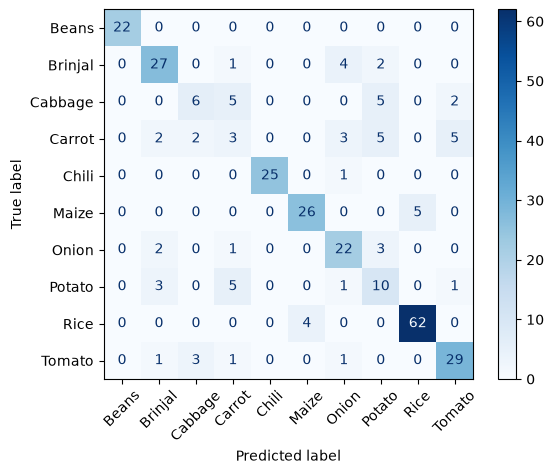

In [11]:
# CONFUSION MATRIX
ConfusionMatrixDisplay.from_predictions(y_test,pred,cmap="Blues",xticks_rotation=45)
plt.show()


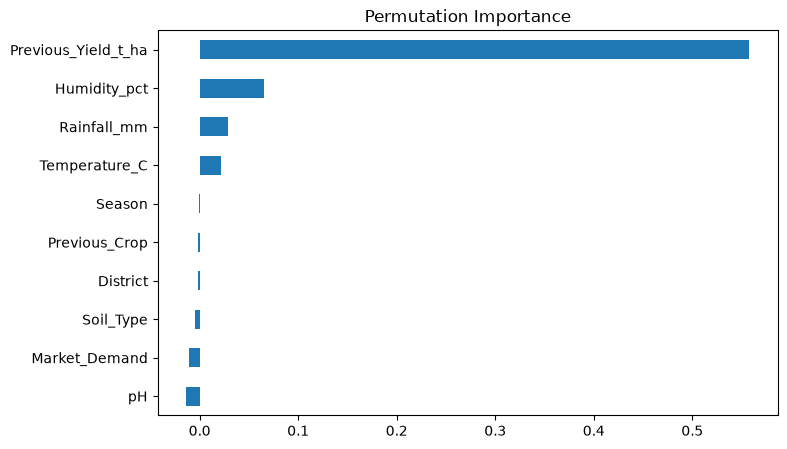

In [12]:
# FEATURE IMPORTANCE
importance=permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
    n_jobs=N_JOBS
)

imp=pd.Series(importance.importances_mean,index=X_test.columns).sort_values()
imp.plot(kind="barh",figsize=(8,5),title="Permutation Importance")
plt.show()


In [13]:
# TEST PREDICTION
sample=X_test.iloc[[0]]
prediction=model.predict(sample)
print("Predicted Crop:",prediction[0])
print("Actual Crop:",y_test.iloc[0])


Predicted Crop: Chili
Actual Crop: Chili
